# **TUẦN 1: 2.1 + 2.2**

In [ ]:
# Cài Java 11 (khuyến nghị cho Spark 3.5.x)
!apt-get update -qq
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

print("Java version:")
!java -version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Java version:
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


In [ ]:
# Cách 2: Tải Spark binary thủ công
!wget -q https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar xf spark-3.5.1-bin-hadoop3.tgz

import os
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"
!pip install findspark -q
import findspark
findspark.init()

In [ ]:
# Khởi tạo SparkSession
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Olist_Preprocessing_Week1_Final") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
print("Spark Session đã khởi tạo thành công!")

Spark Session đã khởi tạo thành công!


In [ ]:
!pip install -q streamlit
print("\nStreamlit installed successfully.")


Streamlit installed successfully.


In [ ]:
!python --version

Python 3.12.13


In [ ]:
!pip install -q gradio

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/datasetCuoiKy/data/olist/"

In [ ]:
base_path = "/content/drive/MyDrive/datasetCuoiKy/"

In [ ]:
# Đọc dữ liệu
# Ensure base_path ends with a slash for correct concatenation
if not base_path.endswith('/'):
    base_path += '/'

orders_df = spark.read.csv(base_path + "olist_orders_dataset.csv", header=True, inferSchema=True)
customers_df = spark.read.csv(base_path + "olist_customers_dataset.csv", header=True, inferSchema=True)
order_items_df = spark.read.csv(base_path + "olist_order_items_dataset.csv", header=True, inferSchema=True)
payments_df = spark.read.csv(base_path + "olist_order_payments_dataset.csv", header=True, inferSchema=True)
reviews_df = spark.read.csv(base_path + "olist_order_reviews_dataset.csv", header=True, inferSchema=True)
products_df = spark.read.csv(base_path + "olist_products_dataset.csv", header=True, inferSchema=True)
sellers_df = spark.read.csv(base_path + "olist_sellers_dataset.csv", header=True, inferSchema=True)
category_df = spark.read.csv(base_path + "product_category_name_translation.csv", header=True, inferSchema=True)
geolocation_df = spark.read.csv(base_path + "olist_geolocation_dataset.csv", header=True, inferSchema=True)
print("Đã đọc xong 9 file CSV")

Đã đọc xong 9 file CSV


In [ ]:
from pyspark.sql.functions import col, sum

def explore_full(df, name):
    print("\n==============================")
    print("DATASET:", name)
    print("==============================")

    # 1. Số dòng
    total_rows = df.count()
    print("Số dòng:", total_rows)

    # 2. Schema
    print("\nSchema:")
    df.printSchema()

    # 3. Dữ liệu mẫu
    print("\n5 dòng đầu:")
    df.show(5, truncate=False)

    # 4. Thống kê mô tả
    print("\nThống kê:")
    df.describe().show()

    # 5. Kiểm tra null
    print("\nSố lượng NULL theo cột:")
    null_df = df.select([
        sum(col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ])
    null_df.show()

    # 6. Kiểm tra duplicate
    unique_rows = df.dropDuplicates().count()
    print("\nDuplicate:")
    print("Tổng:", total_rows)
    print("Unique:", unique_rows)
    print("Số dòng trùng:", total_rows - unique_rows)

In [ ]:
explore_full(customers_df, "customers")


DATASET: customers
Số dòng: 99441

Schema:
root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|customer_id                     |customer_unique_id              |customer_zip_code_prefix|customer_city        |customer_state|
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|06b8999e2fba1a1fbc88172c00ba8bc7|861eff4711a542e4b93843c6dd7febb0|14409                   |franca               |SP            |
|18955e83d337fd6b2def6b18a428ac77|290c77bc529b7ac935b93aa66c333dc3|9790                    |sao bernardo do campo|SP            |
|4e7b3e00288586ebd08712fdd0374a03|060e732b5b29

In [ ]:
explore_full(geolocation_df, "geolocation")


DATASET: geolocation
Số dòng: 1000163

Schema:
root
 |-- geolocation_zip_code_prefix: integer (nullable = true)
 |-- geolocation_lat: double (nullable = true)
 |-- geolocation_lng: double (nullable = true)
 |-- geolocation_city: string (nullable = true)
 |-- geolocation_state: string (nullable = true)


5 dòng đầu:
+---------------------------+-------------------+------------------+----------------+-----------------+
|geolocation_zip_code_prefix|geolocation_lat    |geolocation_lng   |geolocation_city|geolocation_state|
+---------------------------+-------------------+------------------+----------------+-----------------+
|1037                       |-23.54562128115268 |-46.63929204800168|sao paulo       |SP               |
|1046                       |-23.546081127035535|-46.64482029837157|sao paulo       |SP               |
|1046                       |-23.54612896641469 |-46.64295148361138|sao paulo       |SP               |
|1041                       |-23.5443921648681  |-46.63949

In [ ]:
explore_full(order_items_df, "order_items")


DATASET: order_items
Số dòng: 112650

Schema:
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)


5 dòng đầu:
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|order_id                        |order_item_id|product_id                      |seller_id                       |shipping_limit_date|price|freight_value|
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|00010242fe8c5a6d1ba2dd792cb16214|1            |4244733e06e7ecb4970a6e2683c13e61|48436dade18ac8b2bce089ec2a041202|2017-09-19 09:45:35|58.9 |13.29        |
|00018f77

In [ ]:
explore_full(payments_df, "payments")


DATASET: payments
Số dòng: 103886

Schema:
root
 |-- order_id: string (nullable = true)
 |-- payment_sequential: integer (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- payment_installments: integer (nullable = true)
 |-- payment_value: double (nullable = true)


5 dòng đầu:
+--------------------------------+------------------+------------+--------------------+-------------+
|order_id                        |payment_sequential|payment_type|payment_installments|payment_value|
+--------------------------------+------------------+------------+--------------------+-------------+
|b81ef226f3fe1789b1e8b2acac839d17|1                 |credit_card |8                   |99.33        |
|a9810da82917af2d9aefd1278f1dcfa0|1                 |credit_card |1                   |24.39        |
|25e8ea4e93396b6fa0d3dd708e76c1bd|1                 |credit_card |1                   |65.71        |
|ba78997921bbcdc1373bb41e913ab953|1                 |credit_card |8                   |107.7

In [ ]:
explore_full(reviews_df, "reviews")


DATASET: reviews
Số dòng: 104162

Schema:
root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- review_score: string (nullable = true)
 |-- review_comment_title: string (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- review_creation_date: string (nullable = true)
 |-- review_answer_timestamp: string (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------+--------------------+----------------------------------------------------------------------------------------------------+--------------------+-----------------------+
|review_id                       |order_id                        |review_score|review_comment_title|review_comment_message                                                                              |review_creation_date|review_answer_timestamp|
+--------------------------------+--------------------------------+------------+--------------------+---

In [ ]:
explore_full(orders_df, "orders")


DATASET: orders
Số dòng: 99441

Schema:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+-

In [ ]:
explore_full(products_df, "products")


DATASET: products
Số dòng: 32951

Schema:
root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: integer (nullable = true)
 |-- product_description_lenght: integer (nullable = true)
 |-- product_photos_qty: integer (nullable = true)
 |-- product_weight_g: integer (nullable = true)
 |-- product_length_cm: integer (nullable = true)
 |-- product_height_cm: integer (nullable = true)
 |-- product_width_cm: integer (nullable = true)


5 dòng đầu:
+--------------------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|product_id                      |product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_length_cm|product_height_cm|product_width_cm|
+--------------------------------+---------------------+-------------------+---------------------

In [ ]:
explore_full(sellers_df, "sellers")


DATASET: sellers
Số dòng: 3095

Schema:
root
 |-- seller_id: string (nullable = true)
 |-- seller_zip_code_prefix: integer (nullable = true)
 |-- seller_city: string (nullable = true)
 |-- seller_state: string (nullable = true)


5 dòng đầu:
+--------------------------------+----------------------+-----------------+------------+
|seller_id                       |seller_zip_code_prefix|seller_city      |seller_state|
+--------------------------------+----------------------+-----------------+------------+
|3442f8959a84dea7ee197c632cb2df15|13023                 |campinas         |SP          |
|d1b65fc7debc3361ea86b5f14c68d2e2|13844                 |mogi guacu       |SP          |
|ce3ad9de960102d0677a81f5d0bb7b2d|20031                 |rio de janeiro   |RJ          |
|c0f3eea2e14555b6faeea3dd58c1b1c3|4195                  |sao paulo        |SP          |
|51a04a8a6bdcb23deccc82b0b80742cf|12914                 |braganca paulista|SP          |
+--------------------------------+-----------

In [ ]:
explore_full(category_df, "category_translation")


DATASET: category_translation
Số dòng: 71

Schema:
root
 |-- product_category_name: string (nullable = true)
 |-- product_category_name_english: string (nullable = true)


5 dòng đầu:
+----------------------+-----------------------------+
|product_category_name |product_category_name_english|
+----------------------+-----------------------------+
|beleza_saude          |health_beauty                |
|informatica_acessorios|computers_accessories        |
|automotivo            |auto                         |
|cama_mesa_banho       |bed_bath_table               |
|moveis_decoracao      |furniture_decor              |
+----------------------+-----------------------------+
only showing top 5 rows


Thống kê:
+-------+---------------------+-----------------------------+
|summary|product_category_name|product_category_name_english|
+-------+---------------------+-----------------------------+
|  count|                   71|                           71|
|   mean|                 NULL|     

# **TUẦN 1: 2.4.Tiền xử lý dữ liệu**

In [ ]:
from pyspark.sql.functions import *

In [ ]:
# Geolocation
geo_customers = geolocation_df.select(
    col("geolocation_zip_code_prefix").alias("customer_zip_code_prefix"),
    col("geolocation_city").alias("customer_geo_city"),
    col("geolocation_state").alias("customer_geo_state")
).dropDuplicates()

customers_df = customers_df.join(geo_customers, "customer_zip_code_prefix", "left")

geo_sellers = geolocation_df.select(
    col("geolocation_zip_code_prefix").alias("seller_zip_code_prefix"),
    col("geolocation_city").alias("seller_geo_city"),
    col("geolocation_state").alias("seller_geo_state")
).dropDuplicates()

sellers_df = sellers_df.join(geo_sellers, "seller_zip_code_prefix", "left")

In [ ]:
# Timestamp & Cast
orders_df = orders_df \
    .withColumn("order_purchase_timestamp", try_to_timestamp(col("order_purchase_timestamp"))) \
    .withColumn("order_approved_at", try_to_timestamp(col("order_approved_at"))) \
    .withColumn("order_delivered_carrier_date", try_to_timestamp(col("order_delivered_carrier_date"))) \
    .withColumn("order_delivered_customer_date", try_to_timestamp(col("order_delivered_customer_date"))) \
    .withColumn("order_estimated_delivery_date", try_to_timestamp(col("order_estimated_delivery_date")))

reviews_df = reviews_df \
    .withColumn("review_creation_date", try_to_timestamp(col("review_creation_date"))) \
    .withColumn("review_answer_timestamp", try_to_timestamp(col("review_answer_timestamp")))

order_items_df = order_items_df \
    .withColumn("shipping_limit_date", try_to_timestamp(col("shipping_limit_date"))) \
    .withColumn("price", col("price").cast("double")) \
    .withColumn("freight_value", col("freight_value").cast("double"))

payments_df = payments_df.withColumn("payment_value", col("payment_value").cast("double"))

from pyspark.sql.functions import expr

reviews_df = reviews_df \
    .withColumn("review_score", expr("try_cast(review_score as int)"))
#reviews_df = reviews_df.withColumn("review_score", col("review_score").cast("int"))


In [ ]:
# Aggregate
order_items_agg = order_items_df.groupBy("order_id").agg(
    first("product_id").alias("product_id"),
    first("seller_id").alias("seller_id"),
    sum("price").alias("total_price"),
    sum("freight_value").alias("total_freight_value"),
    count("order_item_id").alias("num_items")
)

payments_agg = payments_df.groupBy("order_id").agg(
    sum("payment_value").alias("total_payment_value"),
    first("payment_type").alias("payment_type")
)

In [ ]:
# JOIN
df_master = orders_df.alias("o") \
    .join(customers_df.alias("c"), col("o.customer_id") == col("c.customer_id"), "left") \
    .drop(col("c.customer_id")) \
    .join(order_items_agg.alias("oi"), col("o.order_id") == col("oi.order_id"), "left") \
    .drop(col("oi.order_id")) \
    .join(payments_agg.alias("op"), col("o.order_id") == col("op.order_id"), "left") \
    .drop(col("op.order_id")) \
    .join(reviews_df.alias("r"), col("o.order_id") == col("r.order_id"), "left") \
    .drop(col("r.order_id")) \
    .join(products_df.alias("p"), col("oi.product_id") == col("p.product_id"), "left") \
    .drop(col("p.product_id")) \
    .join(sellers_df.alias("s"), col("oi.seller_id") == col("s.seller_id"), "left") \
    .drop(col("s.seller_id")) \
    .join(category_df.alias("t"), col("p.product_category_name") == col("t.product_category_name"), "left") \
    .drop(col("t.product_category_name"))

In [ ]:
# ================================
# XỬ LÝ MISSING VALUES (FINAL)
# ================================

df_master = df_master.fillna({
    # TEXT
    "review_comment_message": "",
    "review_comment_title": "",

    # CATEGORICAL
    "payment_type": "unknown",
    "product_category_name_english": "unknown",

    # NUMERICAL (logic)
    # Removed "delivery_delay_days": 0, as it's created later
    "num_items": 1,

    # NUMERICAL (bổ sung)
    "total_payment_value": 0,
    "total_price": 0,
    "total_freight_value": 0
})

# Drop key quan trọng
df_master = df_master.dropna(subset=["order_id"])

print("✅ Missing values đã xử lý đầy đủ")

✅ Missing values đã xử lý đầy đủ


In [ ]:
# Feature Engineering
df_master = df_master \
    .withColumn("delivery_delay_days", datediff(col("order_delivered_customer_date"), col("order_estimated_delivery_date"))) \
    .withColumn("total_order_value", col("total_price") + col("total_freight_value")) \
    .withColumn("is_late_delivery", when(col("order_delivered_customer_date") > col("order_estimated_delivery_date"), 1).otherwise(0))

# ÉP 1 DÒNG CHO 1 ORDER_ID
df_master = df_master.dropDuplicates(["order_id"])

In [ ]:
# =====================================
# 10. Kiểm tra kết quả
# =====================================
df_master = df_master.cache()

print("\n" + "="*60)
print("=== KẾT QUẢ SAU TIỀN XỬ LÝ ===")
print("Tổng số bản ghi :", df_master.count())
print("Tổng số cột     :", len(df_master.columns))
print("="*60)

# In Schema
df_master.printSchema()

# Kiểm tra Null counts chi tiết (vertical)
print("\n" + "="*60)
print("NULL COUNTS DETAIL:")
exprs = [count(when(col(c).isNull(), True)).alias(c) for c in df_master.columns]
null_counts = df_master.select(exprs)
null_counts.show(vertical=True, truncate=False)
print("="*60)

# =====================================
# 11. Lưu file Parquet
# =====================================
output_path = base_path + "olist_cleaned...2.parquet"
df_master.write.mode("overwrite").parquet(output_path)
print(f"\nĐã lưu thành công vào: {output_path}")


=== KẾT QUẢ SAU TIỀN XỬ LÝ ===
Tổng số bản ghi : 99441
Tổng số cột     : 44
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- customer_geo_city: string (nullable = true)
 |-- customer_geo_state: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- total_price: double (nullable = false)
 |-- total_freight_value: double (nullable = false)
 |-- num_item

In [ ]:
orders_df.printSchema()
orders_df.describe().show()

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)

+-------+--------------------+--------------------+------------+
|summary|            order_id|         customer_id|order_status|
+-------+--------------------+--------------------+------------+
|  count|               99441|               99441|       99441|
|   mean|                NULL|                NULL|        NULL|
| stddev|                NULL|                NULL|        NULL|
|    min|00010242fe8c5a6d1...|00012a2ce6f8dcda2...|    approved|
|    max|fffe41c64501cc87c...|ffffe8b65bbe3087b...| unavailable|
+-------+--------------------+---------------

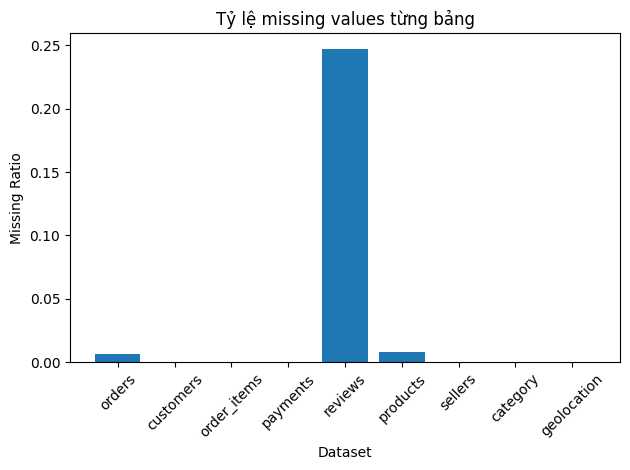

In [ ]:
from pyspark.sql.functions import col, sum
import pandas as pd
import matplotlib.pyplot as plt

# Danh sách các dataframe
dfs = {
    "orders": orders_df,
    "customers": customers_df,
    "order_items": order_items_df,
    "payments": payments_df,
    "reviews": reviews_df,
    "products": products_df,
    "sellers": sellers_df,
    "category": category_df,
    "geolocation": geolocation_df
}

# Tính tỷ lệ missing cho từng bảng
missing_summary = []

for name, df in dfs.items():
    total_rows = df.count()

    null_counts = df.select([
        sum(col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ]).toPandas()

    total_nulls = null_counts.sum(axis=1).values[0]
    total_values = total_rows * len(df.columns)

    missing_ratio = total_nulls / total_values

    missing_summary.append((name, missing_ratio))

# Chuyển sang pandas để vẽ
missing_df = pd.DataFrame(missing_summary, columns=["dataset", "missing_ratio"])

# Vẽ biểu đồ
plt.figure()
plt.bar(missing_df["dataset"], missing_df["missing_ratio"])
plt.xticks(rotation=45)
plt.ylabel("Missing Ratio")
plt.xlabel("Dataset")
plt.title("Tỷ lệ missing values từng bảng")
plt.tight_layout()
plt.show()

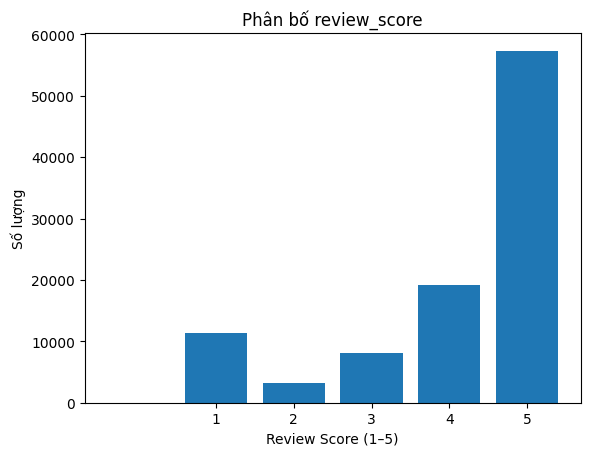

In [ ]:
import matplotlib.pyplot as plt

# Đếm số lượng từng mức review_score
review_dist = reviews_df.groupBy("review_score").count().orderBy("review_score")

# Chuyển sang pandas để vẽ
pdf = review_dist.toPandas()

# Vẽ biểu đồ cột
plt.figure()
plt.bar(pdf["review_score"], pdf["count"])
plt.xlabel("Review Score (1–5)")
plt.ylabel("Số lượng")
plt.title("Phân bố review_score")
plt.xticks([1, 2, 3, 4, 5])
plt.show()

In [ ]:
orders_df.groupBy("order_status").count().show()

+------------+-----+
|order_status|count|
+------------+-----+
|     shipped| 1107|
|    canceled|  625|
|    approved|    2|
|    invoiced|  314|
|     created|    5|
|   delivered|96478|
| unavailable|  609|
|  processing|  301|
+------------+-----+



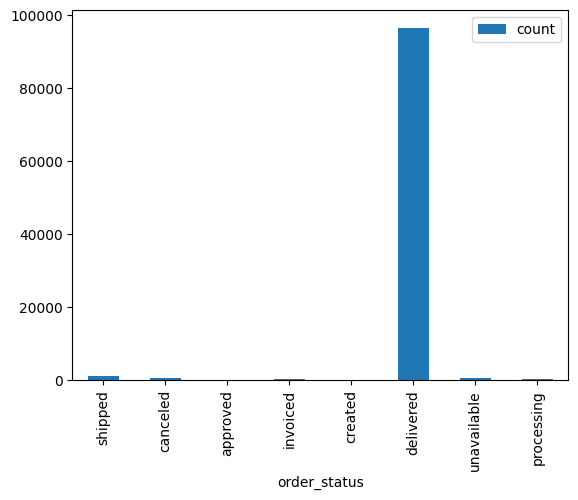

In [ ]:
import matplotlib.pyplot as plt

pdf = orders_df.groupBy("order_status").count().toPandas()
pdf.plot(kind='bar', x='order_status', y='count')
plt.show()